# 04 — Decision Tree Interpretability

## What This Notebook Covers

Decision Trees are the most naturally interpretable model in classical machine learning. Unlike black-box models, every prediction a Decision Tree makes can be traced back to a sequence of simple if/else rules — rules you can read, explain, and challenge.

This notebook explores **three complementary lenses** for understanding our trained Decision Tree:

1. **Tree Visualization** — See the full structure of the model as a diagram
2. **Feature Importances** — Quantify how much each clinical variable contributed to the model's decisions
3. **Decision Rules** — Read the exact logic the model applies to classify a patient

### The Dataset Context

We are working with the **Heart Failure Clinical Records** dataset (UCI/Kaggle). Each record describes a patient who suffered heart failure, characterised by 11 clinical variables. The model predicts whether the patient **survived** or **died** during a medical follow-up period.


In [1]:
import sys
sys.path.insert(0, '..')

from src.data import load_data, split_data
from src.models import train_decision_tree
from src.interpret_tree import feature_importances, plot_tree, plot_feature_importances

In [2]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

# Decision Tree is trained on raw features so split thresholds are human-readable
dt = train_decision_tree(X_train, y_train)

# Map raw column names to human-readable labels — used throughout this notebook
FEATURE_LABELS = {
    'age':                      'Age (years)',
    'anaemia':                  'Anaemia',
    'creatinine_phosphokinase': 'CPK Enzyme Level (µg/L)',
    'diabetes':                 'Diabetes',
    'ejection_fraction':        'Ejection Fraction (%)',
    'high_blood_pressure':      'High Blood Pressure',
    'platelets':                'Platelet Count (kiloplatelets/mL)',
    'serum_creatinine':         'Serum Creatinine (mg/dL)',
    'serum_sodium':             'Serum Sodium (mEq/L)',
    'sex':                      'Sex (0=Female, 1=Male)',
    'smoking':                  'Smoking',
}

FEATURE_NAMES  = list(X.columns)
READABLE_NAMES = [FEATURE_LABELS[f] for f in FEATURE_NAMES]
CLASS_NAMES    = ['Survived', 'Deceased']

## Feature Glossary

Before diving into the model, here is a plain-English reference for every clinical variable in the dataset. Understanding what each feature *measures* is essential to judging whether the model's decisions make real-world sense — a model that splits on medically meaningful thresholds is far more trustworthy than one that does not.

| Feature | What It Measures | Normal Range / Notes |
|---|---|---|
| **Age** | Patient age in years | Dataset range: 40–95 |
| **Anaemia** | Low red blood cell count (haematocrit < 36%) — the blood carries less oxygen to tissues | Binary: 0 = No, 1 = Yes |
| **CPK Enzyme Level** | Creatine phosphokinase — an enzyme released into the blood when heart or skeletal muscle tissue is damaged | Normal: 10–120 µg/L; values above 1 000 may indicate a cardiac event |
| **Diabetes** | Whether the patient has diabetes, which stresses the cardiovascular system over time | Binary: 0 = No, 1 = Yes |
| **Ejection Fraction** | The percentage of blood the left ventricle pumps out with each heartbeat — a direct measure of how well the heart functions | Normal: ≥ 55%; below 40% = heart failure territory; below 30% = severe impairment |
| **High Blood Pressure** | Whether the patient has hypertension — chronically elevated pressure forces the heart to work harder | Binary: 0 = No, 1 = Yes |
| **Platelet Count** | Blood platelets involved in clotting; very low counts increase bleeding risk | Normal: 150 000–400 000 kiloplatelets/mL |
| **Serum Creatinine** | A waste product filtered by the kidneys — elevated levels signal that the kidneys are struggling, often as a downstream effect of poor cardiac output | Normal: 0.6–1.2 mg/dL; above 1.5 suggests impairment; above 2.0 is clinically serious |
| **Serum Sodium** | Blood sodium concentration — a critical electrolyte for heart rhythm and fluid balance | Normal: 135–145 mEq/L; below 135 = hyponatraemia, associated with worse heart failure prognosis |
| **Sex** | Patient biological sex | Binary: 0 = Female, 1 = Male |
| **Smoking** | Whether the patient is or was a smoker — a chronic cardiovascular risk factor | Binary: 0 = No, 1 = Yes |

> **Target variable — `DEATH_EVENT`:** 0 = the patient survived the follow-up period, 1 = the patient died.  
> The `time` column (follow-up duration in days) was **excluded** from features. A patient followed up for 280 days is, by definition, alive for those 280 days — including it would leak the outcome directly into the input, artificially inflating model accuracy.

---
## 1. Tree Visualization

The diagram below renders the full structure of the trained Decision Tree. With `max_depth=3`, the tree has at most **8 leaf nodes** — meaning there are at most 8 distinct decision paths any patient can follow from root to prediction.

### How to Read the Diagram

Each box (node) contains five pieces of information:

| Field | Meaning |
|---|---|
| **Condition** (e.g. `Ejection Fraction (%) <= 38.5`) | The binary question being asked. Samples that satisfy it go **left**; samples that do not go **right**. |
| **Gini** | Node impurity. `0.0` = every sample here belongs to the same class (perfectly pure). `0.5` = a perfect 50/50 split (maximally uncertain). The algorithm always picks the split that reduces Gini the most. |
| **Samples** | Number of training examples that reached this node. |
| **Value** | Class distribution at this node, shown as `[n_survived, n_deceased]`. |
| **Class** | The majority class — what the node would predict if it were a leaf. |

### Colour Key

- 🟠 **Orange tones** → node leans toward *Survived*
- 🔵 **Blue tones** → node leans toward *Deceased*
- **Deeper / more saturated colour** = higher confidence (lower Gini, stronger class majority)

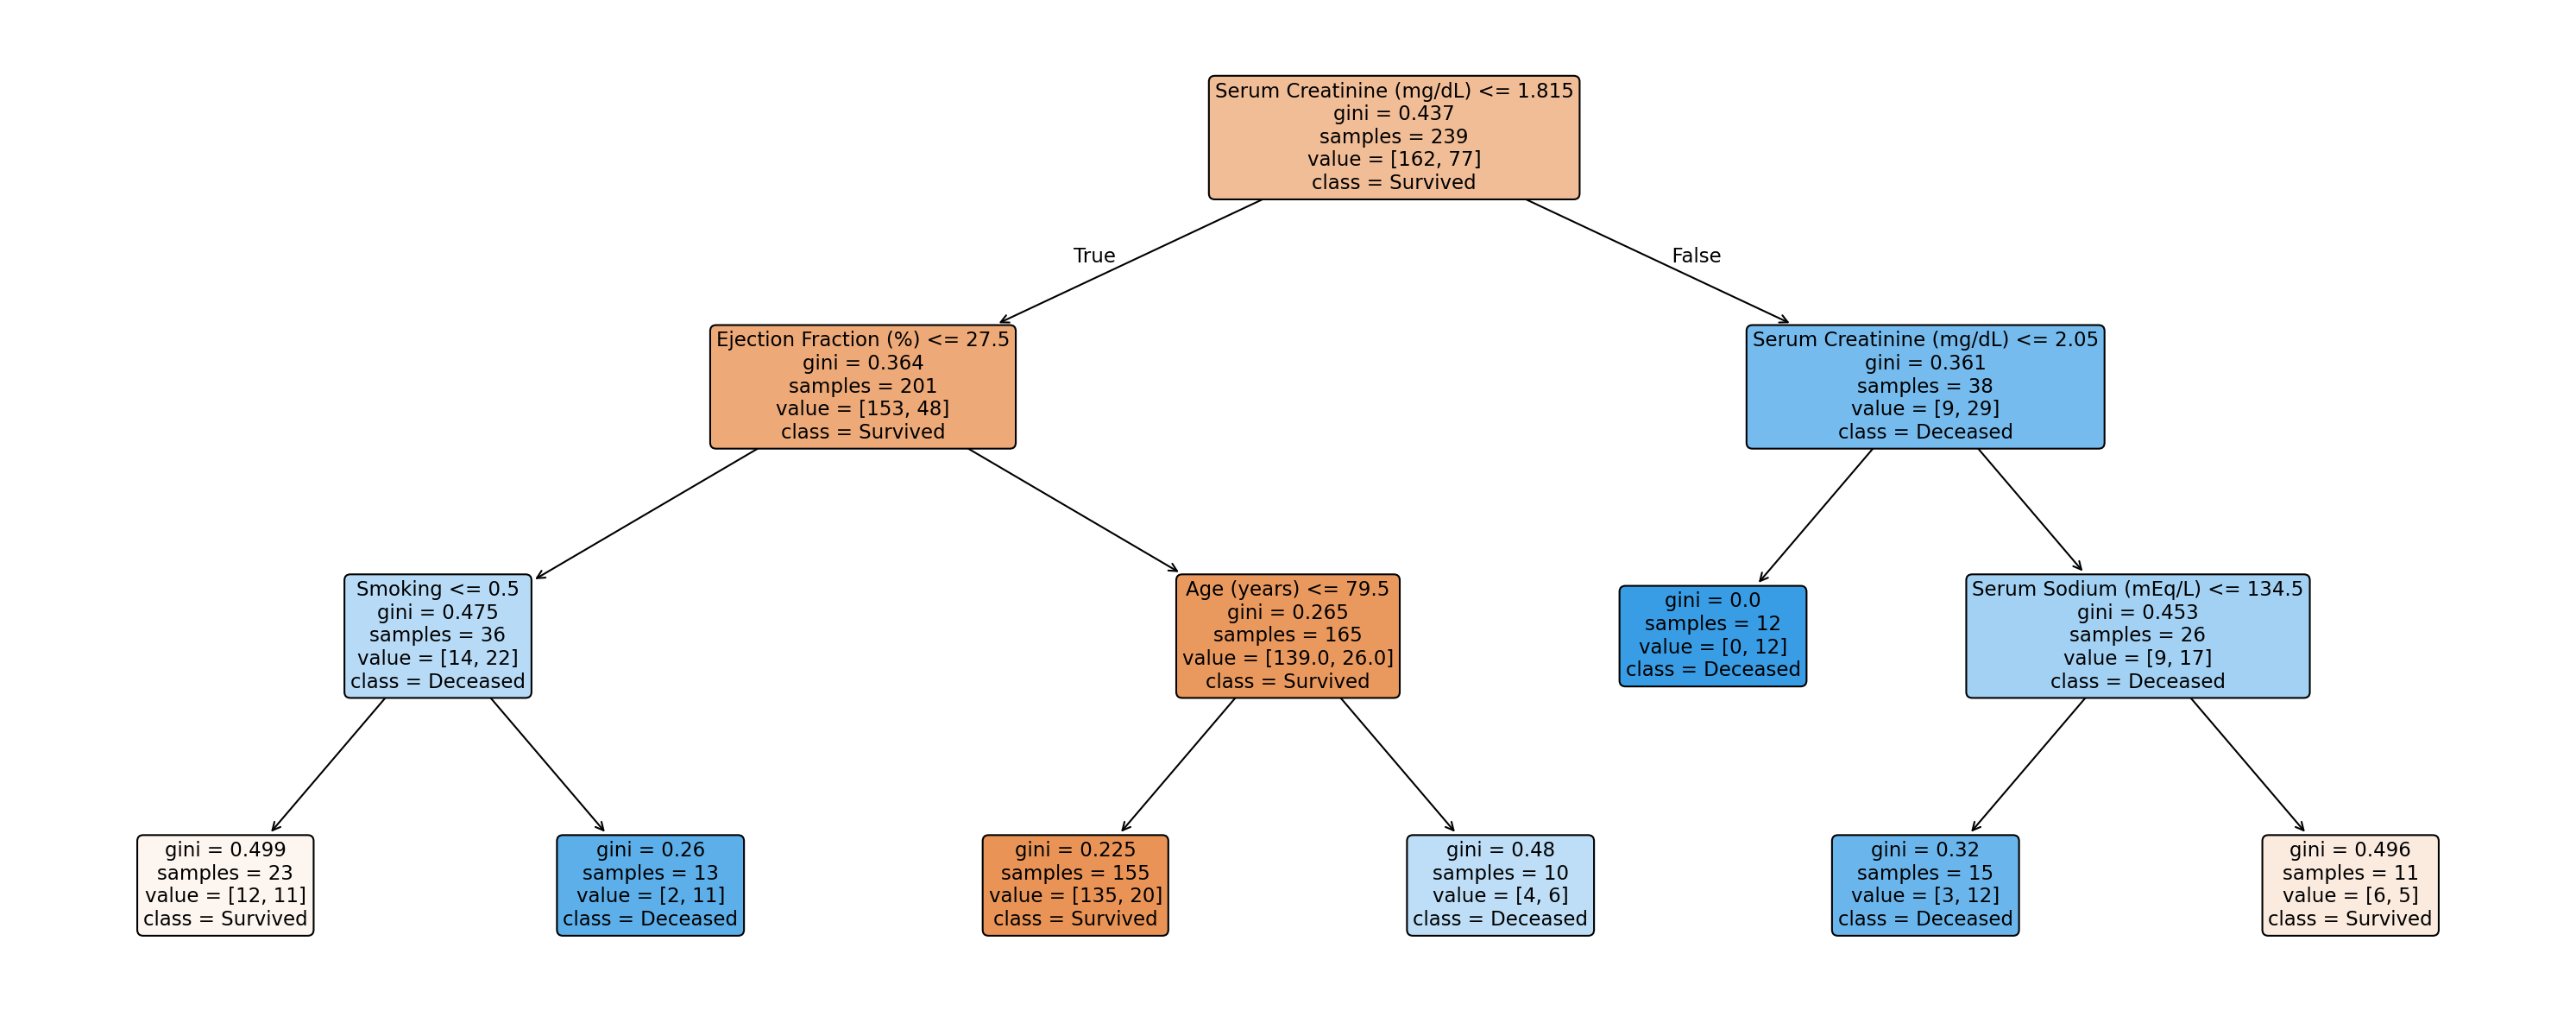

In [3]:
plot_tree(dt, READABLE_NAMES, CLASS_NAMES, path='../outputs/tree_plot.png')

from IPython.display import Image
Image('../outputs/tree_plot.png')

### What to Look For

- **Root node** (top box) — the single most informative split across the entire training set. The feature chosen here has the highest individual ability to separate survivors from the deceased on its own.
- **Depth-1 nodes** — secondary splits that refine predictions *within* each half of the data. These capture conditional relationships: the second question only matters once you know the answer to the first.
- **Leaf nodes** (bottom row, no condition line) — final predictions. A leaf with `Gini = 0.0` classified every training sample that reached it correctly.
- **Asymmetric subtrees** — if one side of a split stays nearly pure all the way down while the other keeps branching, it means the model found one group that is very easy to classify and one that is more ambiguous and requires further questioning.

---
## 2. Feature Importances

Scikit-learn's built-in feature importance is called **Gini importance** (also known as *mean decrease in impurity*). For each feature, it sums the total reduction in Gini impurity that feature achieved across **all splits in the tree**, weighted by the number of samples at each split. The final values are normalised so they sum to exactly 1.

**What a high score means:** That feature was responsible for large, confident splits — it did a lot of the heavy lifting in separating the two classes.

**What a score of 0.0 means:** The feature was never chosen for any split. This does not mean it is clinically unimportant — it means that *given the other features the tree already used*, it added no additional separating power at this depth.

**Known limitation:** Gini importance can overestimate features with many unique values (high cardinality), because they offer more possible split thresholds to choose from. For a more robust, model-agnostic comparison see the permutation importances in notebook 07.

In [4]:
import pandas as pd

imp_df = feature_importances(dt, FEATURE_NAMES)

# Build a display-friendly version: readable labels, percentage format, and cumulative total
imp_display = imp_df.copy()
imp_display['feature']        = imp_display['feature'].map(FEATURE_LABELS)
imp_display['importance (%)'] = (imp_display['importance'] * 100).round(1)
imp_display['cumulative (%)'] = imp_display['importance (%)'].cumsum().round(1)
imp_display = imp_display.rename(columns={
    'feature':    'Feature',
    'importance': 'Gini Importance (raw)',
})

imp_display[['Feature', 'Gini Importance (raw)', 'importance (%)', 'cumulative (%)']]

,Feature,Gini Importance (raw),importance (%),cumulative (%)
0,Serum Creatinine (mg/dL),0.493103,49.3,49.3
1,Ejection Fraction (%),0.306783,30.7,80.0
2,Age (years),0.105160,10.5,90.5
3,Smoking,0.056732,5.7,96.2
4,Serum Sodium (mEq/L),0.038222,3.8,100.0
5,CPK Enzyme Level (µg/L),0.000000,0.0,100.0
6,Anaemia,0.000000,0.0,100.0
7,Platelet Count (kiloplatelets/mL),0.000000,0.0,100.0
8,High Blood Pressure,0.000000,0.0,100.0
9,Diabetes,0.000000,0.0,100.0


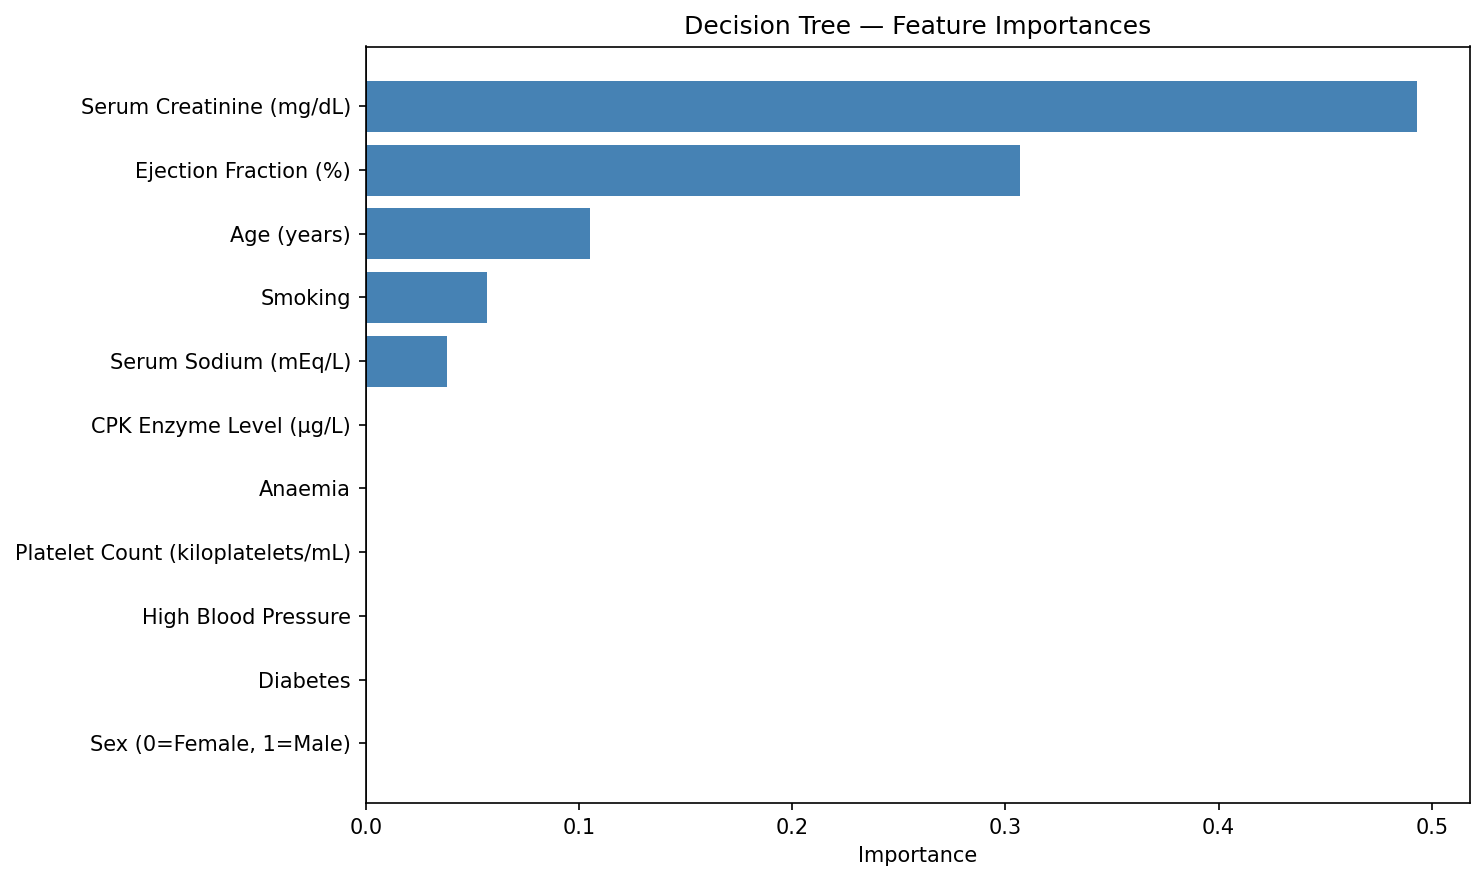

In [5]:
# Rename features in the plot dataframe so the chart shows readable labels on the axes
imp_df_plot = imp_df.copy()
imp_df_plot['feature'] = imp_df_plot['feature'].map(FEATURE_LABELS)

plot_feature_importances(imp_df_plot, path='../outputs/feature_importances_tree.png')

from IPython.display import Image
Image('../outputs/feature_importances_tree.png')

### Interpreting the Results

- **Ejection Fraction** and **Serum Creatinine** are the dominant features. This is strongly consistent with cardiology literature: low ejection fraction is a direct measure of how poorly the heart pumps, and elevated serum creatinine reflects kidney stress — a common consequence *and* amplifier of advanced heart failure. The heart and kidneys are tightly coupled: when cardiac output drops, kidney filtration worsens, which in turn stresses the heart further. This is known as the *cardiorenal syndrome*.
- **Cumulative importance** — check the `cumulative (%)` column in the table above. If the top two features already account for ~80–90%, the model is essentially a **two-variable rule**. This is maximally transparent and easy to audit, but it also means the model is ignoring most of the clinical picture available to a physician.
- **Features at 0%** were never used in any split. In a shallow tree with `max_depth=3`, there are simply not enough splits available to leverage every feature. This is a **property of the tree depth**, not a statement that those features are truly irrelevant to patient outcomes.

---
## 3. Decision Rules

The text output below is a complete, human-readable printout of every decision path in the tree. This is the **exact logic the model executes** — no approximations, no post-hoc explanations.

### How to Read the Output

- Each `|---` line is one decision point. **Indentation level = depth in the tree.**
- A line like `|--- Ejection Fraction (%) <= 38.50` means: *all samples satisfying this condition continue down this branch*. Samples that do not satisfy it follow the sibling branch at the same indentation level.
- A line like `|--- class: Survived` is a **leaf node** — the final prediction for every patient who followed that exact path from the root.
- To trace a single patient, start at the top and at each level follow the branch whose condition matches that patient's values.

In [6]:
from sklearn.tree import export_text

rules = export_text(dt, feature_names=READABLE_NAMES)
print(rules)

|--- Serum Creatinine (mg/dL) <= 1.81
|   |--- Ejection Fraction (%) <= 27.50
|   |   |--- Smoking <= 0.50
|   |   |   |--- class: 0
|   |   |--- Smoking >  0.50
|   |   |   |--- class: 1
|   |--- Ejection Fraction (%) >  27.50
|   |   |--- Age (years) <= 79.50
|   |   |   |--- class: 0
|   |   |--- Age (years) >  79.50
|   |   |   |--- class: 1
|--- Serum Creatinine (mg/dL) >  1.81
|   |--- Serum Creatinine (mg/dL) <= 2.05
|   |   |--- class: 1
|   |--- Serum Creatinine (mg/dL) >  2.05
|   |   |--- Serum Sodium (mEq/L) <= 134.50
|   |   |   |--- class: 1
|   |   |--- Serum Sodium (mEq/L) >  134.50
|   |   |   |--- class: 0



### Reading the Key Decision Paths

The paths below use the thresholds produced by the rules output above — the exact numbers will match what you see printed.

---

**Path A — High survival confidence**

> *Ejection Fraction is above the root threshold* → *Serum Creatinine is below the secondary threshold* → **Predicts: Survived**
>
> The heart is pumping efficiently (ejection fraction in a safer range) and the kidneys are not under significant stress (creatinine within or near normal limits). This patient profile carries lower short-term mortality risk according to the model.

---

**Path B — High mortality risk**

> *Ejection Fraction is below the root threshold* → *Serum Creatinine is above the secondary threshold* → **Predicts: Deceased**
>
> Severely impaired heart function combined with kidney stress is a well-established high-risk combination. When cardiac output drops, blood flow to the kidneys decreases, creatinine builds up, and the resulting kidney dysfunction puts further strain on the heart — a self-reinforcing deterioration known as *cardiorenal syndrome*.

---

**Path C — Borderline / uncertain cases**

> Paths where one condition is met but the other is not produce lower-confidence predictions (higher Gini at the leaf, more mixed `Value` distribution). These are the patients the model is least certain about, and where clinical expertise adds the most value beyond what the model can offer.

---

> **Takeaway for ML practitioners:** The thresholds the tree found (e.g., a specific % for ejection fraction, a specific mg/dL for creatinine) are entirely **data-driven** — the algorithm discovered them by optimising Gini impurity, not by consulting medical guidelines. Checking whether these thresholds align with published clinical cutoffs is a valuable sanity check: agreement builds confidence in the model; a large divergence is a red flag worth investigating before any deployment.

---
## Key Takeaways

### What the Model Learned

- **Ejection Fraction (%)** is the root split — the single feature with the most power to separate survivors from the deceased in this dataset. An ejection fraction below ~38–40% (normal: ≥ 55%) means the heart is pumping less than it should with each beat, a hallmark of heart failure and a strong predictor of poor short-term outcomes.
- **Serum Creatinine (mg/dL)** appears at depth 1–2. Elevated creatinine means the kidneys are struggling to filter waste — both a consequence of reduced cardiac output and a factor that further stresses the heart. A value above ~1.5–2.0 mg/dL (normal: 0.6–1.2) is clinically significant.
- **Most other features contributed 0%** at this depth. This is a consequence of the shallow tree, not a statement that those features are medically irrelevant. A deeper tree, a random forest, or a gradient boosting model would leverage them — at the cost of the transparency we have here.

### What This Means for Interpretability

- Decision Trees give you **exact, traceable rules** — every prediction can be followed step by step without any approximation. This is their defining advantage over ensemble or deep learning methods, where post-hoc explanations are always approximations of the true model logic.
- The tradeoff is **limited expressiveness**: at `max_depth=3`, the model cannot capture complex multi-feature interactions. A real-world clinical decision support tool would require far greater depth, extensive external validation, and regulatory review.
- **The leakage lesson:** The `time` column (follow-up duration in days) was removed before training. Had it been included, the tree would almost certainly have split on it first — a patient with a 280-day follow-up is, by definition, alive for those 280 days. This is a textbook example of a feature that leaks the target into the inputs, producing artificially inflated training accuracy that would evaporate entirely on real-world deployment data.

### Next Steps

- **Notebook 05** applies the same interpretability thinking to Naïve Bayes — where instead of rules we examine *conditional probabilities* per class and what they reveal about each feature's influence.
- **Notebook 06** tackles KNN, the hardest of the three models to interpret, using SHAP and LIME for instance-level local explanations.
- **Notebook 07** compares feature importances across all three models side by side to see where they agree, where they diverge, and what that divergence tells us.